In [38]:
import s3fs
import xarray as xr
import boto3
import gsw
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib
import matplotlib.patches as mpatches
import cmocean
import os
import glob
import imageio
import subprocess
import numpy as np
from tqdm import tqdm

In [39]:
# function to convert GOBAI lon from 20-380 to 0-360
def convert_lons(da, dim='lon'):
    da.coords[dim] = (((360 + (da[dim] % 360)) % 360))
    da_new_lon = da.sortby(da[dim])
    return da_new_lon

## Match float profiles with nearest GOBAI grid cell

In [40]:
def match_climo_float(region,filepath_name, GOBAI_varname, float_varname,lon0,lon1,lat0,lat1):


    s3_path = "s3://uw-escience-scratch-prod/team_mhw/"

    # Open z-axis interpolated float data
    ds_float = xr.open_zarr(s3_path+'regridded_floats/'+region+'_regridded_profiles_full.zarr').compute()
    ds_float = convert_lons(ds_float, dim='LONGITUDE')

    matched_climos = []
    
    for i in tqdm(range(len(GOBAI_varname))):
        # Open z-axis interpolated data product
        ds_GOBAI = xr.open_dataset(
            s3_path + filepath_name[i] + '_2004-2024_monthly_climatology_interpolated_pres_0-1000dbar.nc',
            engine="h5netcdf"
        )
        da_GOBAI = ds_GOBAI[GOBAI_varname[i]].sel(lat=slice(lat0,lat1), lon=slice(lon0,lon1))

        # Read in float variable
        float_profiles = ds_float[float_varname[i]]
        
        # Calculate climatology values matched to nearest float profile location
        matched_climo = da_GOBAI.sel(
            lat=float_profiles['LATITUDE'],
            lon=float_profiles['LONGITUDE'],
            month=float_profiles['JULD'].dt.month,
            method='nearest'
        ).compute()
        
        matched_climo.name = float_varname[i] + '_CLIMO'
        matched_climos.append(matched_climo)
    
    # Merge all climatology variables at once
    ds_float_all = xr.merge([ds_float] + matched_climos,compat='override')
    
    # Save to zarr
    ds_float_all.to_zarr(s3_path + 'regridded_floats/'+region+'_regridded_profiles_with_climo.zarr', mode='w')
    
    return ds_float_all

In [41]:
filepath_name = ['RG09_potential_temperature','RG09_absolute_salinity','GOBAI-O2-v2.3_oxygen','GOBAI-O2-v2.3_oxysat','GOBAI-O2-v2.3_AOU']
GOBAI_varname = ['temp','sal','oxy','oxysat','AOU']
float_varname = ['POTENTIAL_TEMP','ABS_SAL','DOXY','O2_SATURATION','AOU']
# filepath_name = ['RG09_potential_temperature']
# GOBAI_varname = ['temp']
# float_varname = ['POTENTIAL_TEMP']

#SW Pac
# matched_output = match_climo_float('swp',filepath_name, GOBAI_varname, float_varname,
#                                   150,220,-60,-40)
# N Atl
matched_output = match_climo_float('na',filepath_name, GOBAI_varname, float_varname,
                                  290,350,10,60)

  0%|          | 0/5 [00:00<?, ?it/s]

 20%|██        | 1/5 [01:37<06:30, 97.73s/it]

 40%|████      | 2/5 [03:21<05:03, 101.03s/it]

 60%|██████    | 3/5 [05:09<03:28, 104.35s/it]

 80%|████████  | 4/5 [06:52<01:44, 104.03s/it]

100%|██████████| 5/5 [08:33<00:00, 102.65s/it]

100%|██████████| 5/5 [08:33<00:00, 102.62s/it]

In [28]:
region='na'
i=0
s3_path = "s3://uw-escience-scratch-prod/team_mhw/"
lon0=290
lon1=350
lat0=10
lat1=60

# Open z-axis interpolated float data
ds_float = xr.open_zarr(s3_path+'regridded_floats/'+region+'_regridded_profiles_full.zarr').compute()
ds_float = convert_lons(ds_float, dim='LONGITUDE')

# Calculate climatology values matched to nearest float profile location
ds_GOBAI = xr.open_dataset(
    s3_path + filepath_name[i] + '_2004-2024_monthly_climatology_interpolated_pres_0-1000dbar.nc',
    engine="h5netcdf"
)

da_GOBAI = ds_GOBAI[GOBAI_varname[i]].sel(lat=slice(lat0,lat1), lon=slice(lon0,lon1))

# matched_climo = da_GOBAI.sel(
#     lat=float_profiles['LATITUDE'],
#     lon=float_profiles['LONGITUDE'],
#     month=float_profiles['JULD'].dt.month,
#     method='nearest'
#     ).compute()

In [29]:
ds_float

<xarray.Dataset> Size: 56MB
Dimensions:          (profile: 994, pres: 1001)
Coordinates:
    CYCLE_NUMBER     (profile) int64 8kB 144 266 176 141 106 142 ... 9 31 23 5 3
    JULD             (profile) datetime64[ns] 8kB 2023-04-06T13:20:58 ... 202...
    LATITUDE         (profile) float64 8kB -41.97 -48.72 -55.74 ... -50.9 -55.63
    LONGITUDE        (profile) float64 8kB 150.0 150.0 150.1 ... 220.0 220.0
    PLATFORM_NUMBER  (profile) <U7 28kB '5905441' '5906623' ... '5906542'
  * pres             (pres) int64 8kB 0 1 2 3 4 5 6 ... 995 996 997 998 999 1000
  * profile          (profile) int64 8kB 115 843 111 132 240 ... 610 41 773 579
Data variables:
    ABS_SAL          (profile, pres) float64 8MB nan nan nan ... 34.68 34.68
    AOU              (profile, pres) float64 8MB nan nan nan ... 155.2 155.2
    CHLA             (profile, pres) float64 8MB nan nan ... 0.001662 0.001662
    DOXY             (profile, pres) float64 8MB nan nan nan ... 171.2 171.1
    O2_SATURATION    (profile, pres) float64 8MB nan nan nan ... 326.3 326.3
    POTENTIAL_TEMP   (profile, pres) float64 8MB nan nan nan ... 2.672 2.671
    TEMP             (profile, pres) float64 8MB nan nan nan ... 2.738 2.737
Attributes:
    depth_units:  decibar
    max_depth:    1000
    region:       swp

In [14]:
# matched_output

<xarray.Dataset> Size: 64MB
Dimensions:               (profile: 994, pres: 1001)
Coordinates:
    CYCLE_NUMBER          (profile) int64 8kB 144 266 176 141 106 ... 31 23 5 3
    JULD                  (profile) datetime64[ns] 8kB 2023-04-06T13:20:58 .....
    LATITUDE              (profile) float64 8kB -41.97 -48.72 ... -50.9 -55.63
    LONGITUDE             (profile) float64 8kB 150.0 150.0 ... 220.0 220.0
    PLATFORM_NUMBER       (profile) <U7 28kB '5905441' '5906623' ... '5906542'
  * pres                  (pres) int64 8kB 0 1 2 3 4 5 ... 996 997 998 999 1000
  * profile               (profile) int64 8kB 115 843 111 132 ... 610 41 773 579
    lon                   (profile) float32 4kB 290.5 290.5 ... 290.5 290.5
    lat                   (profile) float32 4kB 10.5 10.5 10.5 ... 10.5 10.5
    month                 (profile) int64 8kB 4 4 10 4 4 4 4 ... 3 1 3 10 1 2 12
Data variables:
    ABS_SAL               (profile, pres) float64 8MB nan nan ... 34.68 34.68
    AOU                   (profile, pres) float64 8MB nan nan ... 155.2 155.2
    CHLA                  (profile, pres) float64 8MB nan nan ... 0.001662
    DOXY                  (profile, pres) float64 8MB nan nan ... 171.2 171.1
    O2_SATURATION         (profile, pres) float64 8MB nan nan ... 326.3 326.3
    POTENTIAL_TEMP        (profile, pres) float64 8MB nan nan ... 2.672 2.671
    TEMP                  (profile, pres) float64 8MB nan nan ... 2.738 2.737
    POTENTIAL_TEMP_CLIMO  (profile, pres) float64 8MB nan nan nan ... nan nan
Attributes:
    depth_units:  decibar
    max_depth:    1000
    region:       swp

In [33]:
# open SWPac MHW mask
matched_output = xr.open_zarr(f's3://uw-escience-scratch-prod/team_mhw/regridded_floats/swp_regridded_profiles_with_climo.zarr').compute()
mhw_swp_mask = xr.open_zarr(f's3://uw-escience-scratch-prod/oisst/mhw_mask_swp_final.zarr').compute()
float_profiles_mhw_mask = mhw_swp_mask['mhw_mask'].sel(lat=matched_output['LATITUDE'],
                                                       lon=matched_output['LONGITUDE'],
                                                       time=matched_output['JULD'].dt.date,
                                                       method='nearest')
mhw_float = matched_output.where(float_profiles_mhw_mask==1, np.nan, drop=True)
non_mhw_float = matched_output.where(float_profiles_mhw_mask==0, np.nan, drop=True)

In [22]:
non_mhw_float

<xarray.Dataset> Size: 72MB
Dimensions:               (profile: 751, pres: 1001)
Coordinates:
    CYCLE_NUMBER          (profile) int64 6kB 144 266 176 141 106 ... 9 23 5 3
    JULD                  (profile) datetime64[ns] 6kB 2023-04-06T13:20:58 .....
    LATITUDE              (profile) float64 6kB -41.97 -48.72 ... -50.9 -55.63
    LONGITUDE             (profile) float64 6kB 150.0 150.0 ... 220.0 220.0
    PLATFORM_NUMBER       (profile) <U7 21kB '5905441' '5906623' ... '5906542'
  * pres                  (pres) int64 8kB 0 1 2 3 4 5 ... 996 997 998 999 1000
  * profile               (profile) int64 6kB 115 843 111 132 ... 785 41 773 579
    month                 (profile) int64 6kB 4 4 10 4 4 4 4 ... 2 4 1 3 1 2 12
    time                  (profile) datetime64[ns] 6kB 2023-04-06T12:00:00 .....
Data variables:
    ABS_SAL               (profile, pres) float64 6MB nan nan ... 34.68 34.68
    AOU                   (profile, pres) float64 6MB nan nan ... 155.2 155.2
    CHLA                  (profile, pres) float64 6MB nan nan ... 0.001662
    DOXY                  (profile, pres) float64 6MB nan nan ... 171.2 171.1
    O2_SATURATION         (profile, pres) float64 6MB nan nan ... 326.3 326.3
    POTENTIAL_TEMP        (profile, pres) float64 6MB nan nan ... 2.672 2.671
    TEMP                  (profile, pres) float64 6MB nan nan ... 2.738 2.737
    POTENTIAL_TEMP_CLIMO  (profile, pres) float64 6MB 17.96 17.96 ... 2.584
    ABS_SAL_CLIMO         (profile, pres) float64 6MB 35.72 35.72 ... 34.68
    DOXY_CLIMO            (profile, pres) float64 6MB 237.7 237.6 ... 176.5
    O2_SATURATION_CLIMO   (profile, pres) float64 6MB 233.3 233.3 ... 327.1
    AOU_CLIMO             (profile, pres) float64 6MB -4.378 -4.297 ... 150.5
Attributes:
    depth_units:  decibar
    max_depth:    1000
    region:       swp

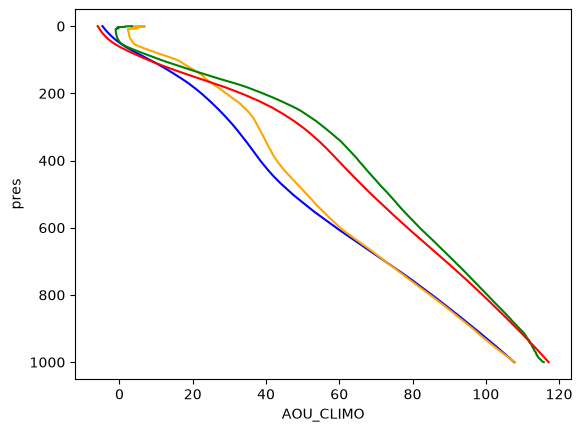

In [34]:
# matched_output['POTENTIAL_TEMP_CLIMO']
# matched_output['POTENTIAL_TEMP']
# matched_output['POTENTIAL_TEMP_CLIMO'].mean('profile').plot(y='pres')
mhw_float['AOU_CLIMO'].mean('profile').plot(y='pres',color='blue')
mhw_float['AOU'].mean('profile').plot(y='pres',color='orange')
non_mhw_float['AOU'].mean('profile').plot(y='pres',color='green')
non_mhw_float['AOU_CLIMO'].mean('profile').plot(y='pres',color='red')

plt.gca().invert_yaxis()

# mhw_float['POTENTIAL_TEMP_CLIMO'].mean('profile').plot(y='pres',color='blue')
# mhw_float['POTENTIAL_TEMP'].mean('profile').plot(y='pres',color='orange')
# plt.gca().invert_yaxis()


## preliminary anomaly plots relative to GOBAI T, S, and O2 climatologies

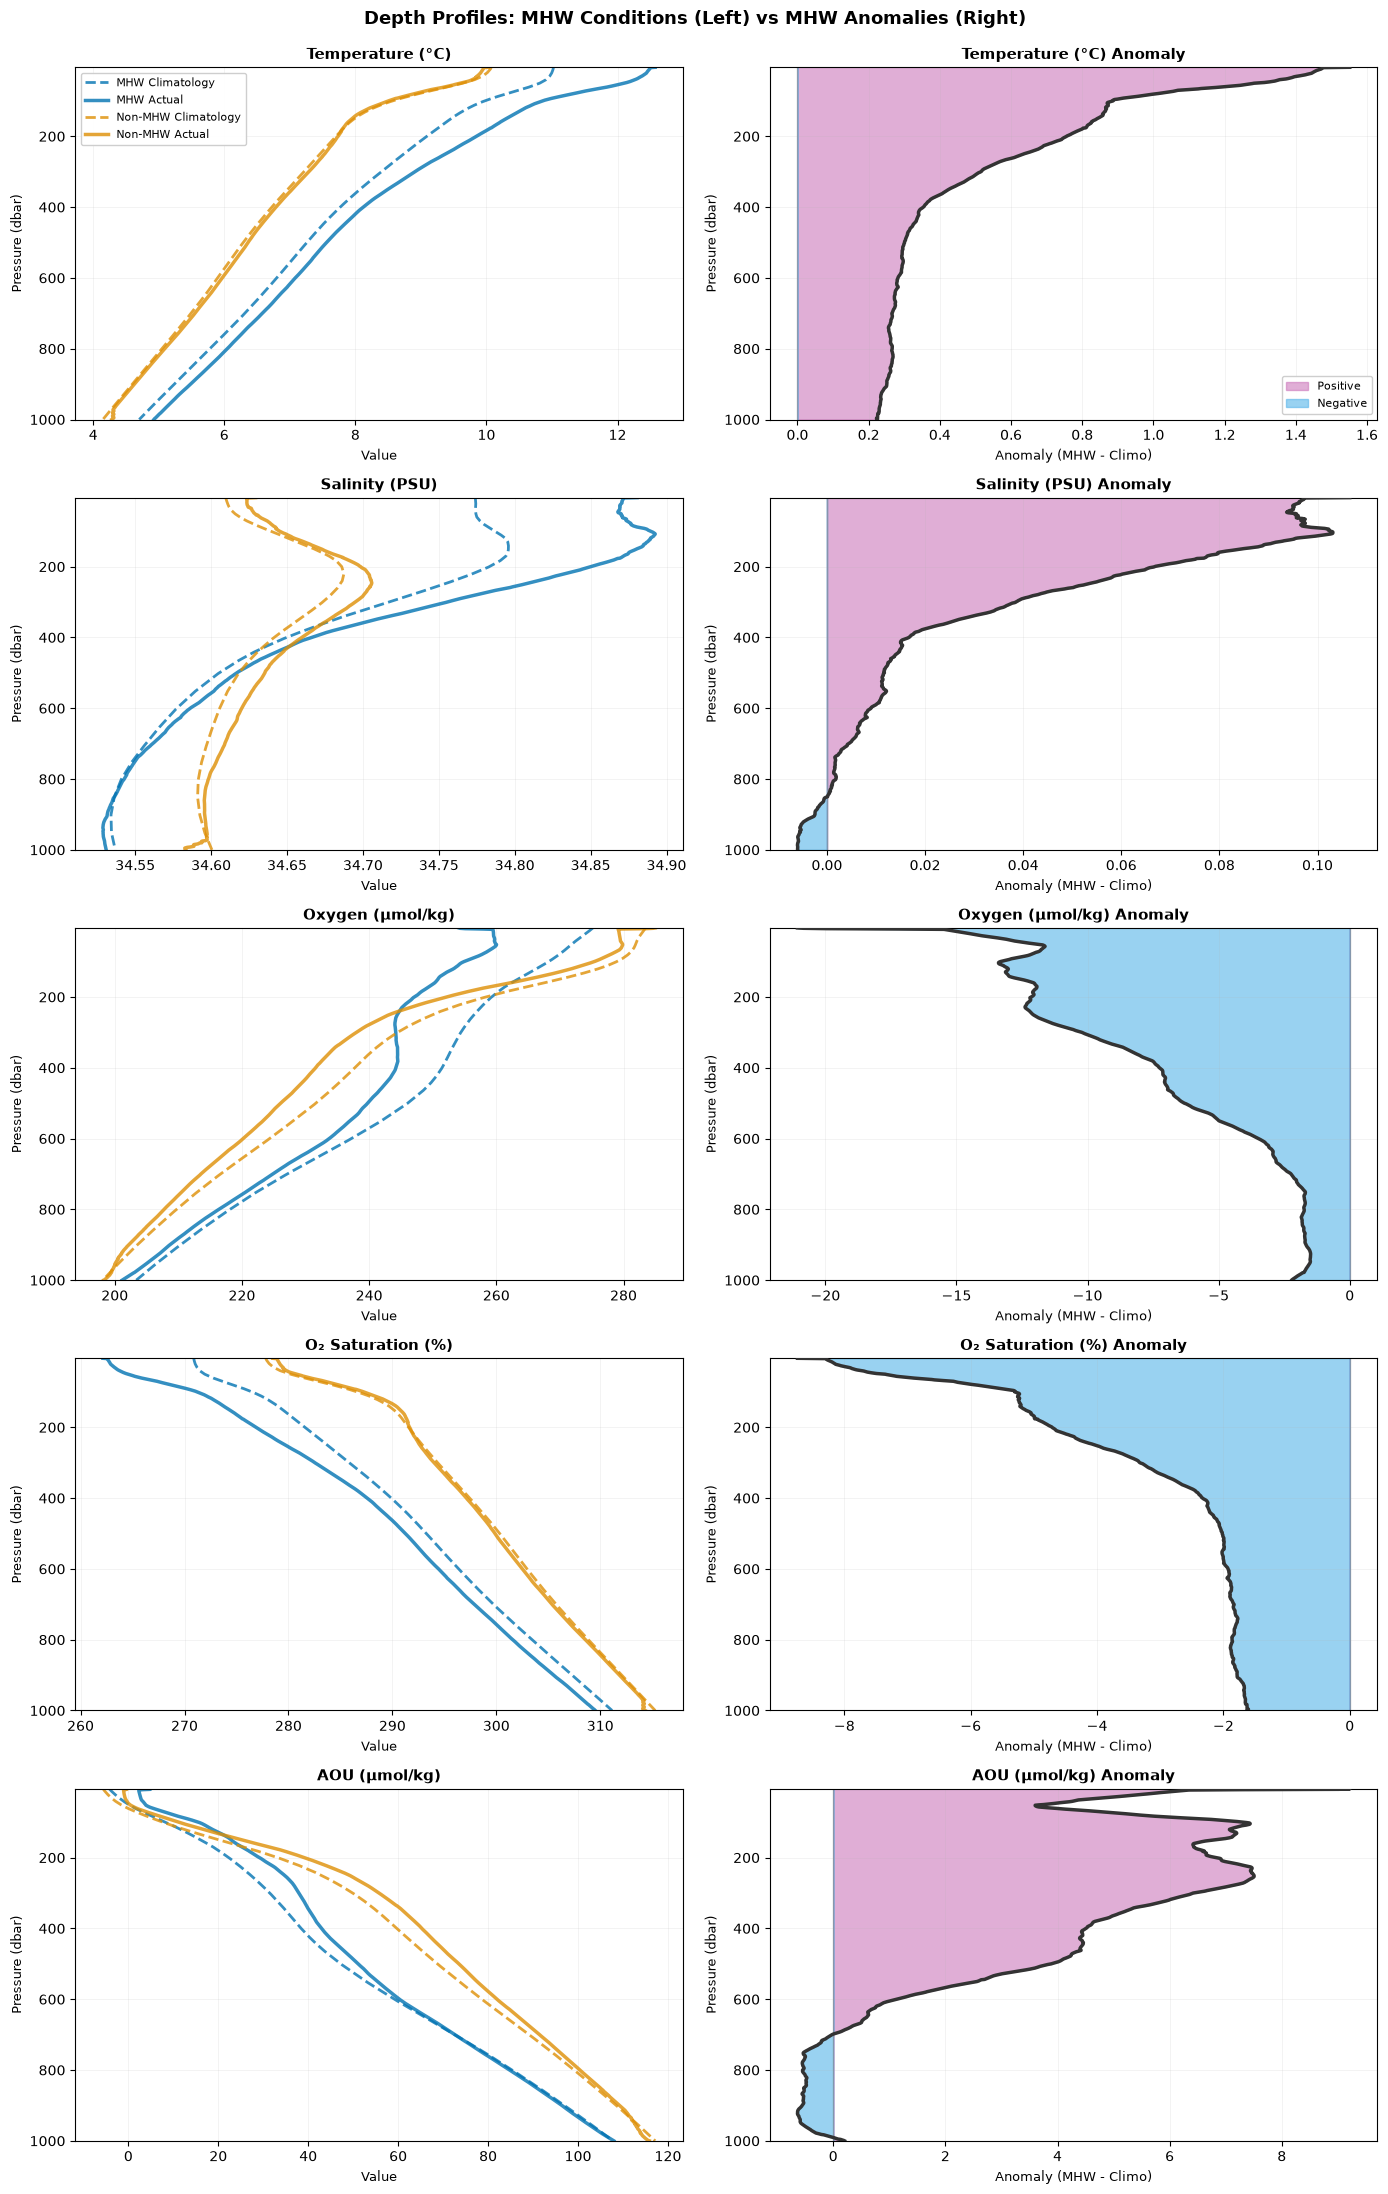

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Define your variables with better labels
variables = {
    'POTENTIAL_TEMP': 'Temperature (°C)',
    'ABS_SAL': 'Salinity (PSU)', 
    'DOXY': 'Oxygen (μmol/kg)',
    'O2_SATURATION': 'O₂ Saturation (%)',
    'AOU': 'AOU (μmol/kg)'
}

# Create figure with 5 rows x 2 columns
fig, axes = plt.subplots(5, 2, figsize=(14, 22))

# Color palette: categorical hues for MHW condition (left column)
colors = {
    'mhw': '#0173B2',        # Blue
    'non_mhw': '#DE8F05'     # Orange
}

# Line styles: solid for actual, dashed for climatology
styles = {
    'actual': '-',
    'climo': '--'
}

# Diverging colors for anomalies (right column)
colors_anom = {
    'positive': '#CC78BC',   # Purple-magenta for positive anomaly
    'negative': '#56B4E9'    # Light blue for negative anomaly
}

# Plot each variable
for idx, (var_key, var_label) in enumerate(variables.items()):
    climo_name = f'{var_key}_CLIMO'
    
    # LEFT COLUMN: Condition comparison
    ax_left = axes[idx, 0]
    
    # Plot MHW data
    mhw_float[climo_name].mean('profile').where(mhw_float['pres'] >= 5).plot(
        y='pres', ax=ax_left, 
        color=colors['mhw'], linestyle=styles['climo'], 
        linewidth=2, label='MHW Climatology', alpha=0.8
    )
    mhw_float[var_key].mean('profile').where(mhw_float['pres'] >= 5).plot(
        y='pres', ax=ax_left,
        color=colors['mhw'], linestyle=styles['actual'],
        linewidth=2.5, label='MHW Actual', alpha=0.8
    )
    
    # Plot non-MHW data
    non_mhw_float[climo_name].mean('profile').where(non_mhw_float['pres'] >= 5).plot(
        y='pres', ax=ax_left,
        color=colors['non_mhw'], linestyle=styles['climo'],
        linewidth=2, label='Non-MHW Climatology', alpha=0.8
    )
    non_mhw_float[var_key].mean('profile').where(non_mhw_float['pres'] >= 5).plot(
        y='pres', ax=ax_left,
        color=colors['non_mhw'], linestyle=styles['actual'],
        linewidth=2.5, label='Non-MHW Actual', alpha=0.8
    )
    
    ax_left.set_title(var_label, fontsize=11, fontweight='bold')
    ax_left.set_xlabel('Value', fontsize=9)
    ax_left.set_ylabel('Pressure (dbar)', fontsize=9)
    ax_left.invert_yaxis()
    ax_left.set_ylim(1000, 5)
    ax_left.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
    
    # Legend only on first row
    if idx == 0:
        ax_left.legend(loc='best', fontsize=8, framealpha=0.95)
    
    # RIGHT COLUMN: Anomalies
    ax_right = axes[idx, 1]
    
    # Calculate anomaly: MHW actual - MHW climatology
    anomaly = (mhw_float[var_key].mean('profile').where(mhw_float['pres'] >= 5) - 
               mhw_float[climo_name].mean('profile').where(mhw_float['pres'] >= 5))
    
    # Plot anomaly with diverging colors
    # Split positive and negative for better visual separation
    anomaly_pos = anomaly.where(anomaly >= 0, 0)
    anomaly_neg = anomaly.where(anomaly < 0, 0)
    
    ax_right.plot(anomaly, mhw_float['pres'], 
                  color='#333333', linewidth=2.5, zorder=3)
    ax_right.fill_betweenx(mhw_float['pres'], 0, anomaly_pos, 
                           color=colors_anom['positive'], alpha=0.6, label='Positive')
    ax_right.fill_betweenx(mhw_float['pres'], 0, anomaly_neg, 
                           color=colors_anom['negative'], alpha=0.6, label='Negative')
    ax_right.axvline(x=0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
    
    ax_right.set_title(f'{var_label} Anomaly', fontsize=11, fontweight='bold')
    ax_right.set_xlabel('Anomaly (MHW - Climo)', fontsize=9)
    ax_right.set_ylabel('Pressure (dbar)', fontsize=9)
    ax_right.invert_yaxis()
    ax_right.set_ylim(1000, 5)
    ax_right.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
    
    # Legend only on first row
    if idx == 0:
        ax_right.legend(loc='best', fontsize=8, framealpha=0.95)

plt.suptitle('Depth Profiles: MHW Conditions (Left) vs MHW Anomalies (Right)', 
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

fig.savefig('/home/jovyan/Marine-Heat-Waves/contributors/stevie/figures/SWPac_depth_profile_anomaly_comparison.png')

#### seasonal

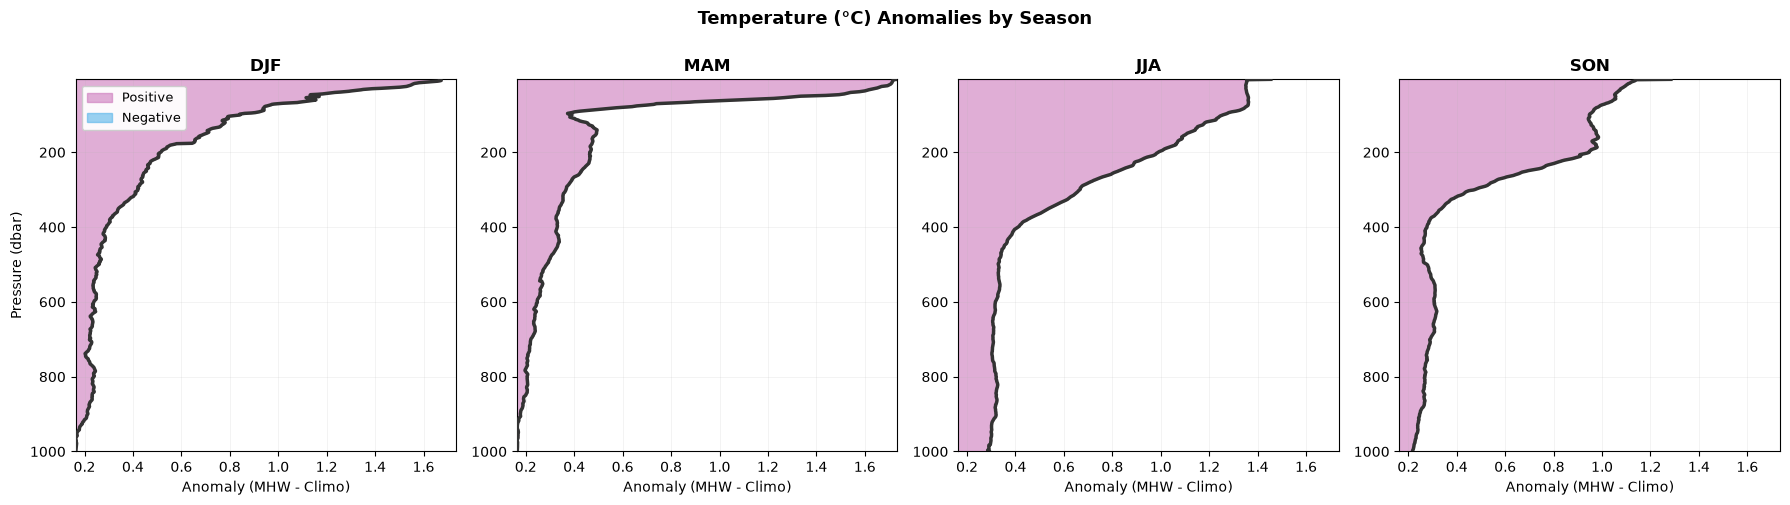

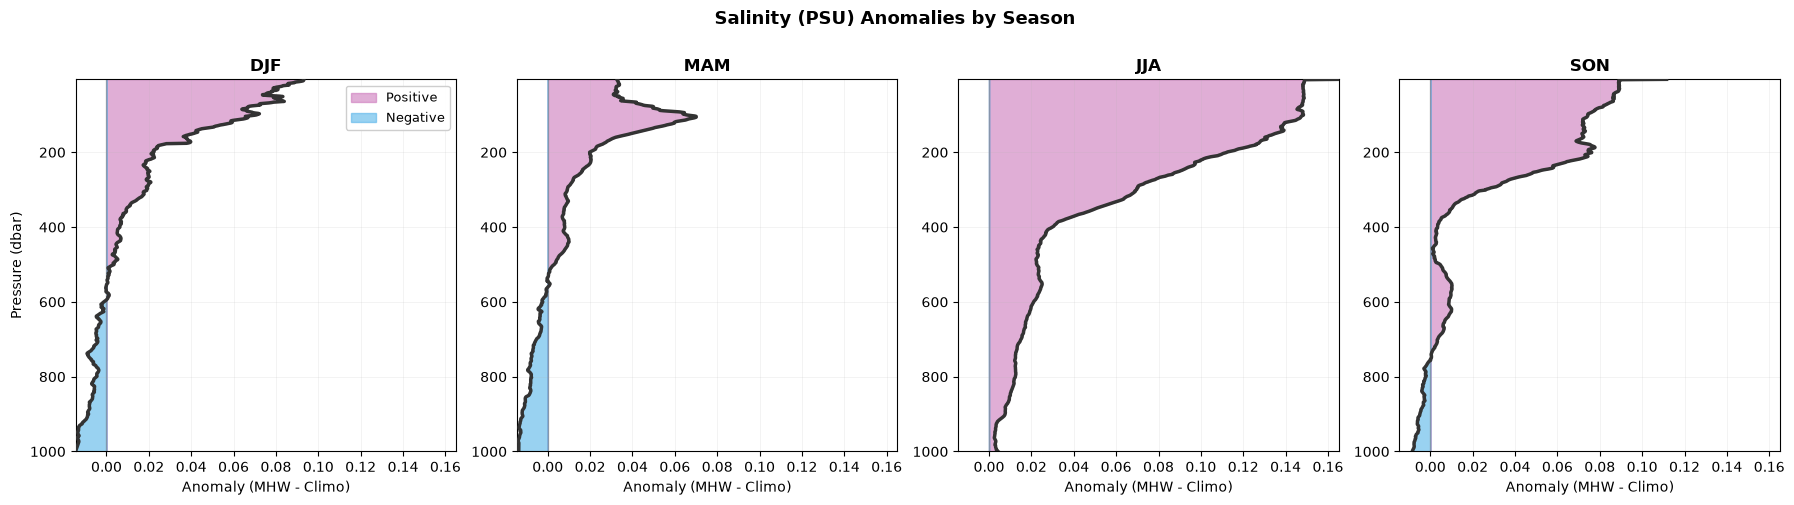

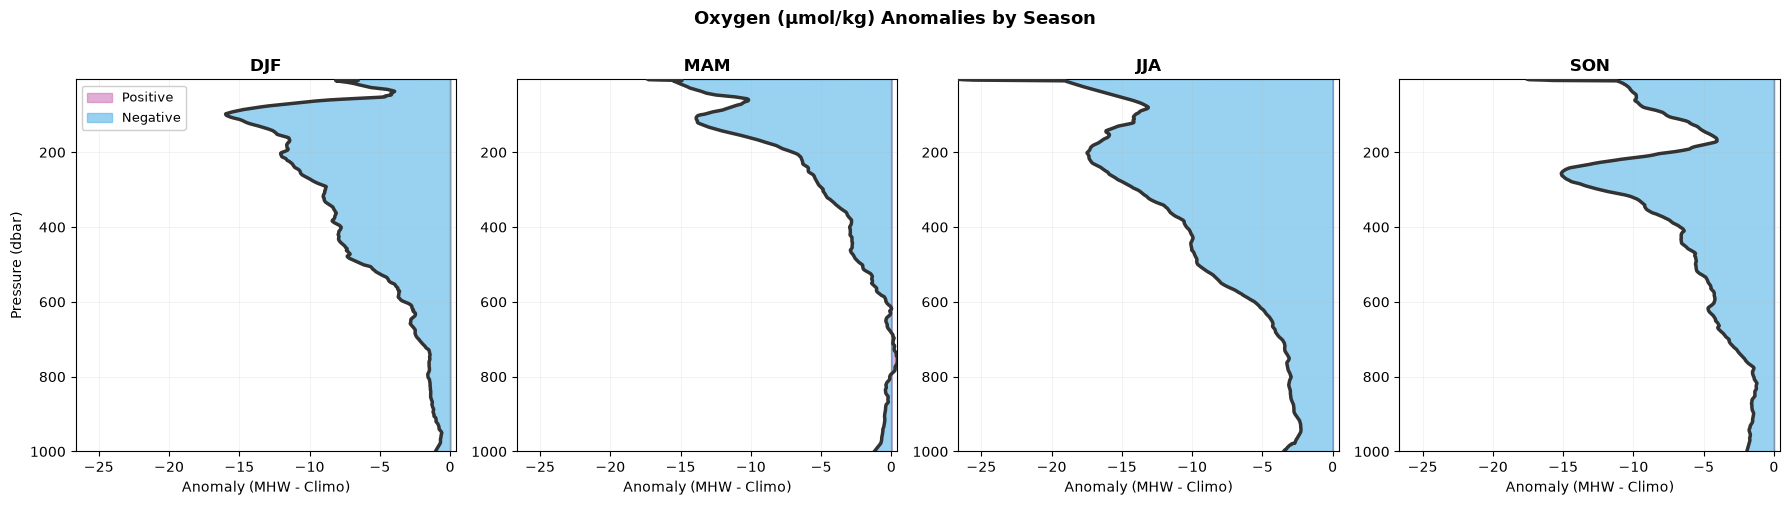

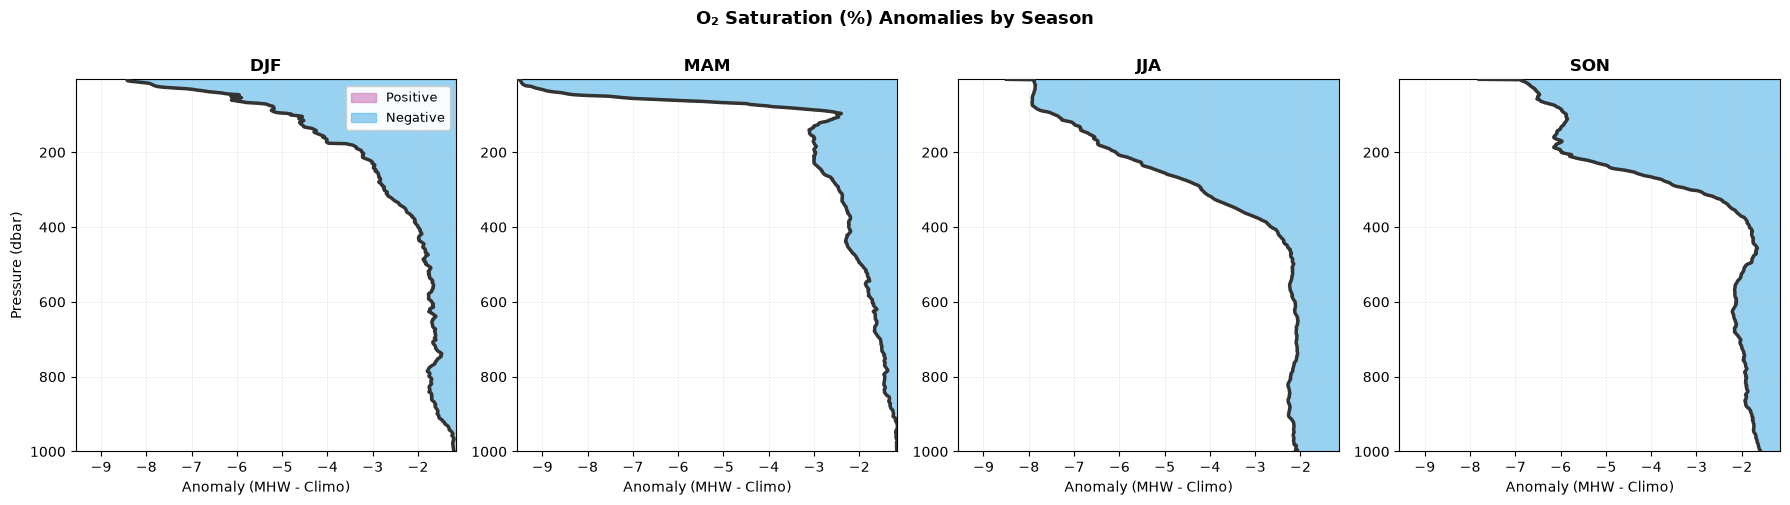

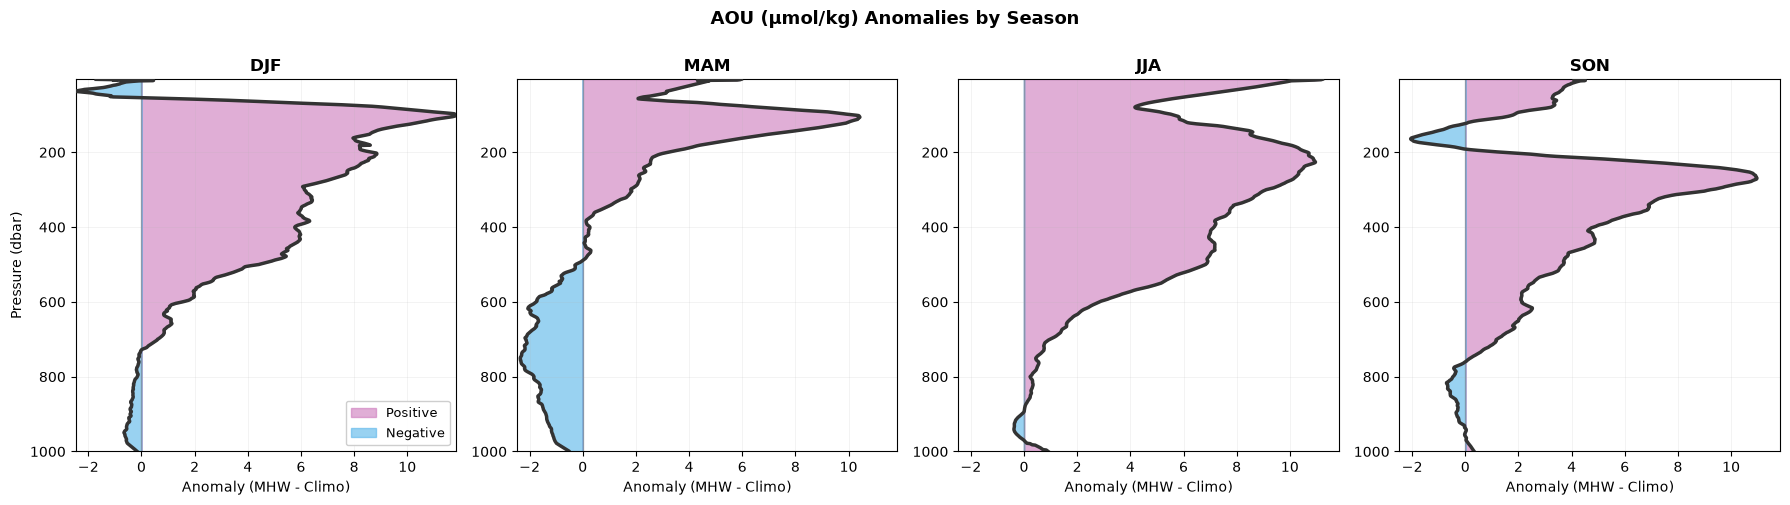

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Define your variables with better labels
variables = {
    'POTENTIAL_TEMP': 'Temperature (°C)',
    'ABS_SAL': 'Salinity (PSU)', 
    'DOXY': 'Oxygen (μmol/kg)',
    'O2_SATURATION': 'O₂ Saturation (%)',
    'AOU': 'AOU (μmol/kg)'
}

# Define seasons (month groups)
seasons = {
    'DJF': [12, 1, 2],
    'MAM': [3, 4, 5],
    'JJA': [6, 7, 8],
    'SON': [9, 10, 11]
}

# Diverging colors for anomalies
colors_anom = {
    'positive': '#CC78BC',   # Purple-magenta for positive anomaly
    'negative': '#56B4E9'    # Light blue for negative anomaly
}

# Create a figure for each variable
for var_key, var_label in variables.items():
    climo_name = f'{var_key}_CLIMO'
    
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    
    # First pass: calculate all anomalies to find axis limits
    anomalies = {}
    for season_name, months in seasons.items():
        mhw_season = mhw_float.sel(profile=mhw_float['time.month'].isin(months))
        anomaly = (mhw_season[var_key].mean('profile').where(mhw_season['pres'] >= 5) - 
                   mhw_season[climo_name].mean('profile').where(mhw_season['pres'] >= 5))
        anomalies[season_name] = anomaly
    
    # Find global min and max for x-axis
    all_values = np.concatenate([anomalies[s].values[~np.isnan(anomalies[s].values)] for s in seasons.keys()])
    x_min = np.min(all_values)
    x_max = np.max(all_values)
    
    # Plot each season
    for season_idx, (season_name, months) in enumerate(seasons.items()):
        ax = axes[season_idx]
        mhw_season = mhw_float.sel(profile=mhw_float['time.month'].isin(months))
        anomaly = anomalies[season_name]
        
        # Plot anomaly with diverging colors
        # Split positive and negative for better visual separation
        anomaly_pos = anomaly.where(anomaly >= 0, 0)
        anomaly_neg = anomaly.where(anomaly < 0, 0)
        
        ax.plot(anomaly, mhw_season['pres'], 
                color='#333333', linewidth=2.5, zorder=3)
        ax.fill_betweenx(mhw_season['pres'], 0, anomaly_pos, 
                         color=colors_anom['positive'], alpha=0.6, label='Positive')
        ax.fill_betweenx(mhw_season['pres'], 0, anomaly_neg, 
                         color=colors_anom['negative'], alpha=0.6, label='Negative')
        ax.axvline(x=0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
        
        ax.set_title(f'{season_name}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Anomaly (MHW - Climo)', fontsize=10)
        if season_idx == 0:
            ax.set_ylabel('Pressure (dbar)', fontsize=10)
        ax.invert_yaxis()
        ax.set_ylim(1000, 5)
        ax.set_xlim(x_min, x_max)
        ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
        
        # Legend only on first panel
        if season_idx == 0:
            ax.legend(loc='best', fontsize=9, framealpha=0.95)
    
    plt.suptitle(f'{var_label} Anomalies by Season', 
                 fontsize=13, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()


### North Atlantic

In [42]:
# open NAtl MHW mask
matched_output = xr.open_zarr(f's3://uw-escience-scratch-prod/team_mhw/regridded_floats/na_regridded_profiles_with_climo.zarr').compute()
mhw_swp_mask = xr.open_zarr(f's3://uw-escience-scratch-prod/oisst/mhw_mask_na_final.zarr').compute()
float_profiles_mhw_mask = mhw_swp_mask['mhw_mask'].sel(lat=matched_output['LATITUDE'],
                                                       lon=matched_output['LONGITUDE'],
                                                       time=matched_output['JULD'].dt.date,
                                                       method='nearest')
mhw_float = matched_output.where(float_profiles_mhw_mask==1, np.nan, drop=True)
non_mhw_float = matched_output.where(float_profiles_mhw_mask==0, np.nan, drop=True)

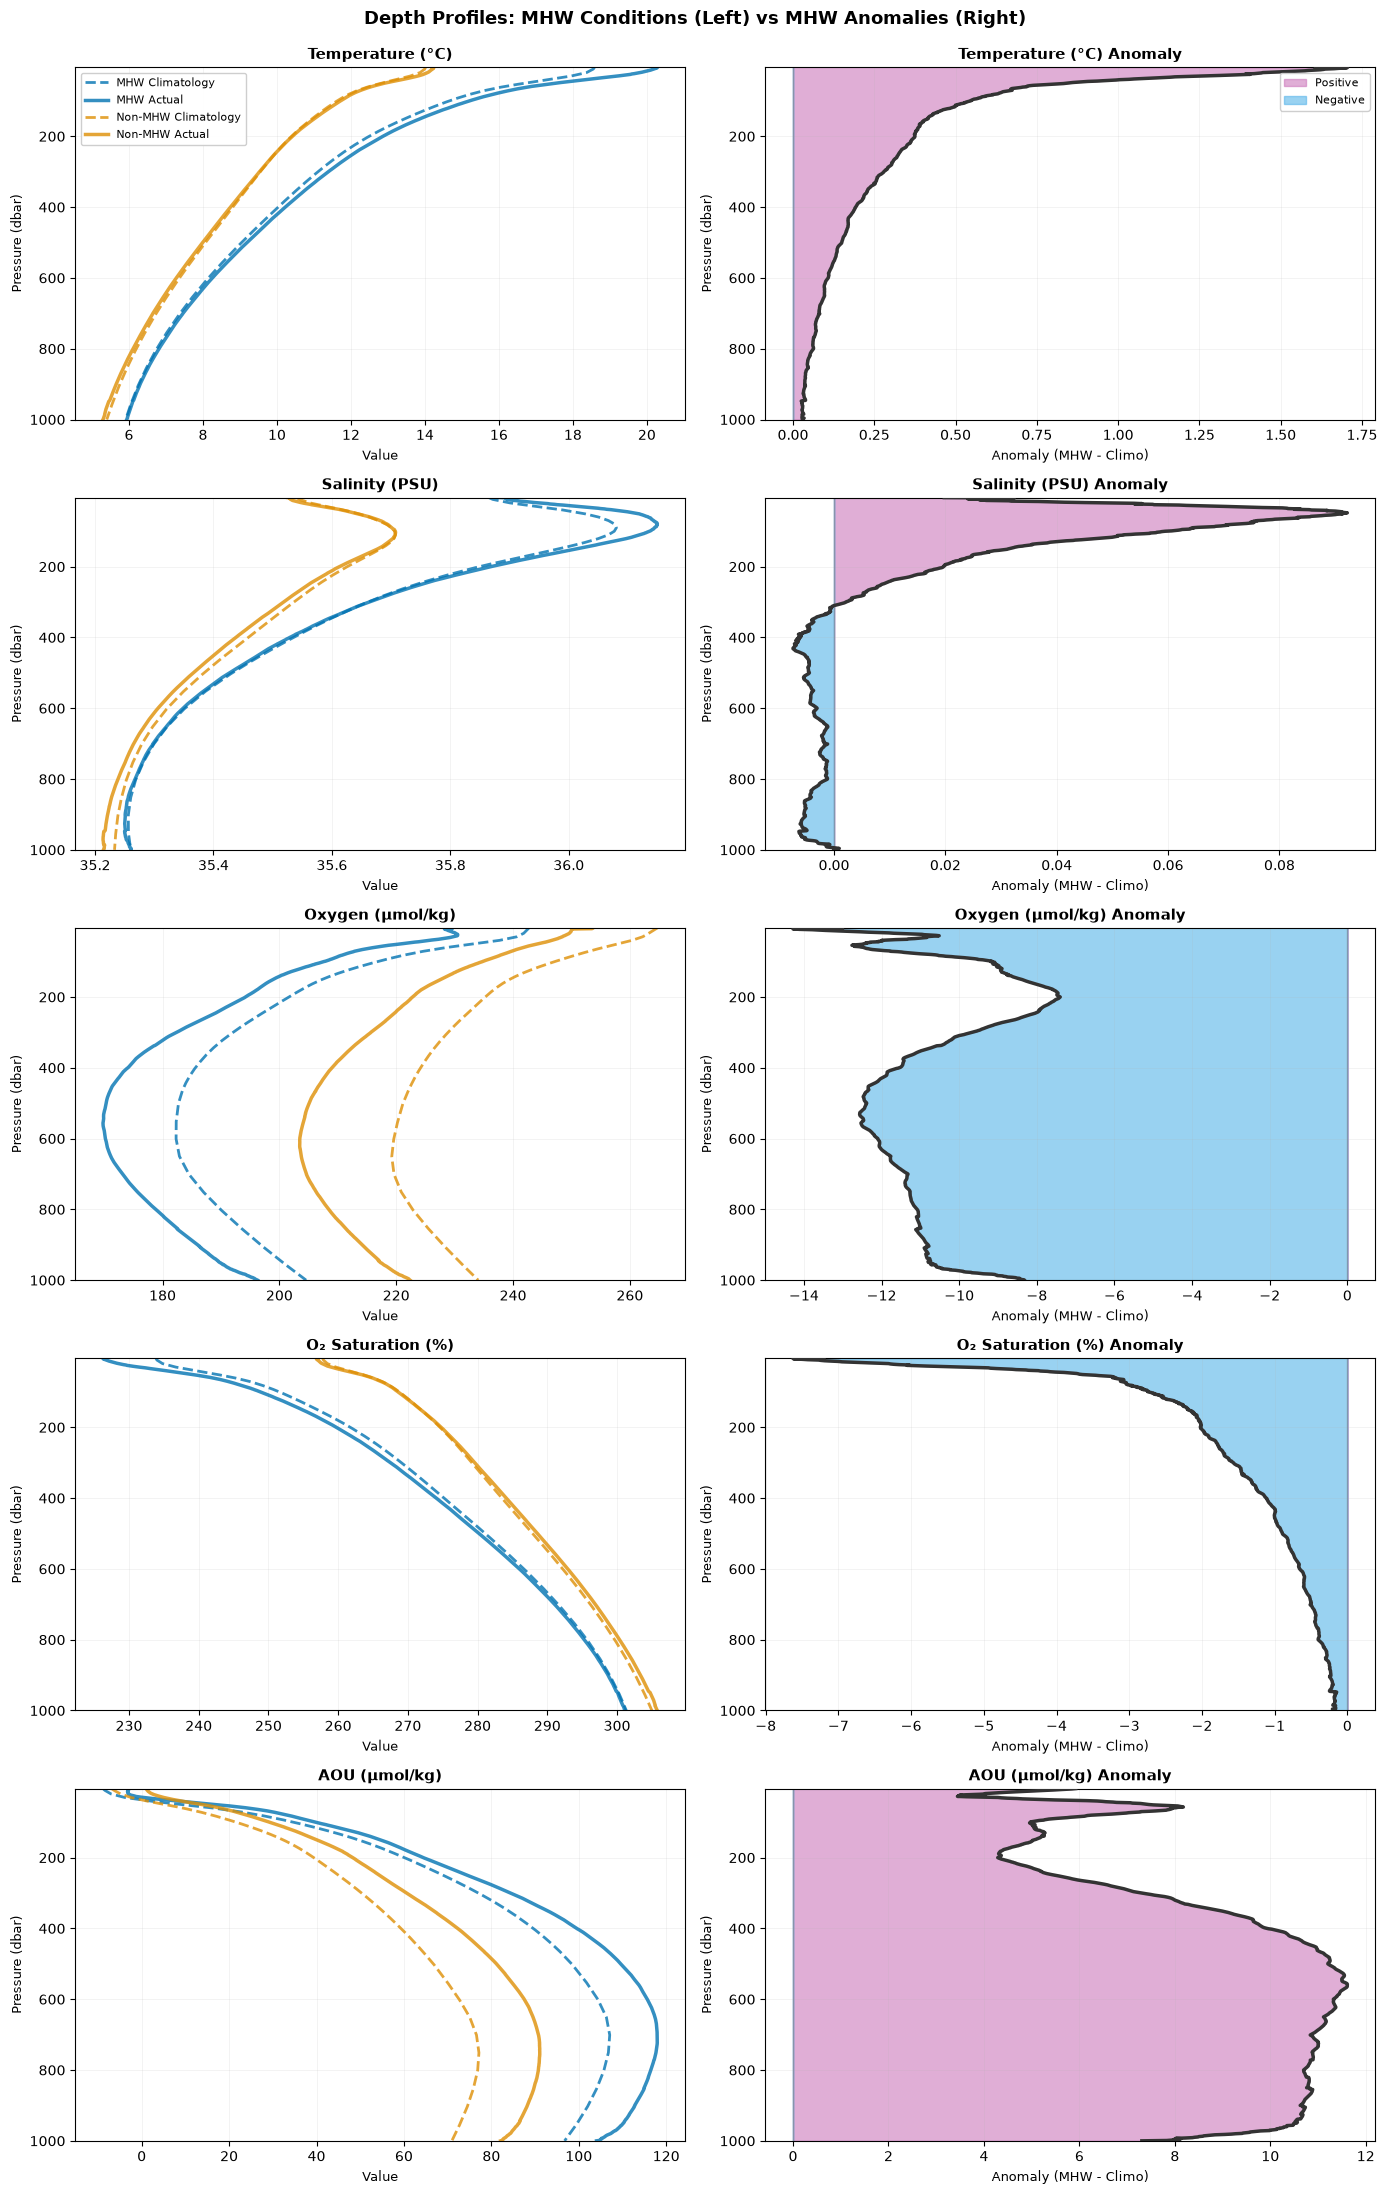

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Define your variables with better labels
variables = {
    'POTENTIAL_TEMP': 'Temperature (°C)',
    'ABS_SAL': 'Salinity (PSU)', 
    'DOXY': 'Oxygen (μmol/kg)',
    'O2_SATURATION': 'O₂ Saturation (%)',
    'AOU': 'AOU (μmol/kg)'
}

# Create figure with 5 rows x 2 columns
fig, axes = plt.subplots(5, 2, figsize=(14, 22))

# Color palette: categorical hues for MHW condition (left column)
colors = {
    'mhw': '#0173B2',        # Blue
    'non_mhw': '#DE8F05'     # Orange
}

# Line styles: solid for actual, dashed for climatology
styles = {
    'actual': '-',
    'climo': '--'
}

# Diverging colors for anomalies (right column)
colors_anom = {
    'positive': '#CC78BC',   # Purple-magenta for positive anomaly
    'negative': '#56B4E9'    # Light blue for negative anomaly
}

# Plot each variable
for idx, (var_key, var_label) in enumerate(variables.items()):
    climo_name = f'{var_key}_CLIMO'
    
    # LEFT COLUMN: Condition comparison
    ax_left = axes[idx, 0]
    
    # Plot MHW data
    mhw_float[climo_name].mean('profile').where(mhw_float['pres'] >= 5).plot(
        y='pres', ax=ax_left, 
        color=colors['mhw'], linestyle=styles['climo'], 
        linewidth=2, label='MHW Climatology', alpha=0.8
    )
    mhw_float[var_key].mean('profile').where(mhw_float['pres'] >= 5).plot(
        y='pres', ax=ax_left,
        color=colors['mhw'], linestyle=styles['actual'],
        linewidth=2.5, label='MHW Actual', alpha=0.8
    )
    
    # Plot non-MHW data
    non_mhw_float[climo_name].mean('profile').where(non_mhw_float['pres'] >= 5).plot(
        y='pres', ax=ax_left,
        color=colors['non_mhw'], linestyle=styles['climo'],
        linewidth=2, label='Non-MHW Climatology', alpha=0.8
    )
    non_mhw_float[var_key].mean('profile').where(non_mhw_float['pres'] >= 5).plot(
        y='pres', ax=ax_left,
        color=colors['non_mhw'], linestyle=styles['actual'],
        linewidth=2.5, label='Non-MHW Actual', alpha=0.8
    )
    
    ax_left.set_title(var_label, fontsize=11, fontweight='bold')
    ax_left.set_xlabel('Value', fontsize=9)
    ax_left.set_ylabel('Pressure (dbar)', fontsize=9)
    ax_left.invert_yaxis()
    ax_left.set_ylim(1000, 5)
    ax_left.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
    
    # Legend only on first row
    if idx == 0:
        ax_left.legend(loc='best', fontsize=8, framealpha=0.95)
    
    # RIGHT COLUMN: Anomalies
    ax_right = axes[idx, 1]
    
    # Calculate anomaly: MHW actual - MHW climatology
    anomaly = (mhw_float[var_key].mean('profile').where(mhw_float['pres'] >= 5) - 
               mhw_float[climo_name].mean('profile').where(mhw_float['pres'] >= 5))
    
    # Plot anomaly with diverging colors
    # Split positive and negative for better visual separation
    anomaly_pos = anomaly.where(anomaly >= 0, 0)
    anomaly_neg = anomaly.where(anomaly < 0, 0)
    
    ax_right.plot(anomaly, mhw_float['pres'], 
                  color='#333333', linewidth=2.5, zorder=3)
    ax_right.fill_betweenx(mhw_float['pres'], 0, anomaly_pos, 
                           color=colors_anom['positive'], alpha=0.6, label='Positive')
    ax_right.fill_betweenx(mhw_float['pres'], 0, anomaly_neg, 
                           color=colors_anom['negative'], alpha=0.6, label='Negative')
    ax_right.axvline(x=0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
    
    ax_right.set_title(f'{var_label} Anomaly', fontsize=11, fontweight='bold')
    ax_right.set_xlabel('Anomaly (MHW - Climo)', fontsize=9)
    ax_right.set_ylabel('Pressure (dbar)', fontsize=9)
    ax_right.invert_yaxis()
    ax_right.set_ylim(1000, 5)
    ax_right.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
    
    # Legend only on first row
    if idx == 0:
        ax_right.legend(loc='best', fontsize=8, framealpha=0.95)

plt.suptitle('Depth Profiles: MHW Conditions (Left) vs MHW Anomalies (Right)', 
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [11]:
s3_path = "s3://uw-escience-scratch-prod/team_mhw/"
#open GOBAI climatology
GOBAI_varname = 'temp'
float_varname = 'TEMP'
filepath_varname = 'RG09_potential_temperature'
ds_GOBAI = xr.open_dataset(s3_path+filepath_varname+'_2004-2024_monthly_climatology_interpolated_pres_0-1000dbar.nc', engine="h5netcdf")
da_GOBAI = ds_GOBAI[GOBAI_varname].sel(lat = slice(-60,-40),lon = slice(150,220))

#open interpolated float data
ds_float = xr.open_zarr(s3_path+'regridded_floats/swp_regridded_profiles_full.zarr').compute()
ds_float = convert_lons(ds_float,dim='LONGITUDE')
float_profiles = ds_float[float_varname]


In [12]:
# open SWPac MHW mask
mhw_swp_mask = xr.open_zarr(f's3://uw-escience-scratch-prod/oisst/mhw_mask_swp_final.zarr').compute()

In [15]:
# float_profiles_180 = xr.open_zarr('s3://uw-escience-scratch-prod/team_mhw/regridded_floats/swp_regridded_profiles_full.zarr').compute()
# float_profiles = convert_lons(float_profiles_180, dim='LONGITUDE')
# da_float = float_profiles[float_varname]

In [13]:
float_profiles_mhw_mask = mhw_swp_mask['mhw_mask'].sel(lat=float_profiles['LATITUDE'],
                                                       lon=float_profiles['LONGITUDE'],
                                                       time=float_profiles['JULD'].dt.date,
                                                       method='nearest')

In [14]:
mhw_float = float_profiles.where(float_profiles_mhw_mask==1, np.nan, drop=True)
non_mhw_float = float_profiles.where(float_profiles_mhw_mask==0, np.nan, drop=True)

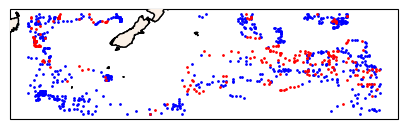

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5), subplot_kw={'projection': ccrs.PlateCarree(180)})
ax.coastlines(resolution = "50m", zorder=5, linewidth = 1)
ax.add_feature(cfeature.LAND, zorder=5, linewidth = 1, edgecolor='k', facecolor='linen')
# ax.set_global()

ax.scatter(non_mhw_float.lon, non_mhw_float.lat, c='blue', s=1, transform=ccrs.PlateCarree())
ax.scatter(mhw_float.lon, mhw_float.lat, c='r', s=1, transform=ccrs.PlateCarree())
# ax.scatter(float_profiles.LONGITUDE, float_profiles.LATITUDE, c='r', s=1, transform=ccrs.PlateCarree())

plt.show()

In [16]:
matched_climo = da_GOBAI.sel(lat=mhw_float['LATITUDE'],
                       lon=mhw_float['LONGITUDE'],
                       month=mhw_float['JULD'].dt.month,
                       method='nearest').compute()

In [17]:
matched_climo

<xarray.DataArray 'temp' (profile: 243, pres: 1001)> Size: 2MB
array([[17.0830953 , 17.08136818, 17.07964105, ...,  5.32442197,
         5.31791716,  5.31141235],
       [19.63646053, 19.6324178 , 19.62837507, ...,  5.06807986,
         5.06199294,  5.05590602],
       [19.63646053, 19.6324178 , 19.62837507, ...,  5.06807986,
         5.06199294,  5.05590602],
       ...,
       [ 8.27077805,  8.27011784,  8.26945763, ...,  5.12308472,
         5.11696749,  5.11085027],
       [ 6.7402542 ,  6.73947321,  6.73869221, ...,  2.71774188,
         2.71651141,  2.71528093],
       [ 7.86857149,  7.86761604,  7.86666059, ...,  4.55581791,
         4.5503347 ,  4.54485148]], shape=(243, 1001))
Coordinates:
    lon              (profile) float32 972B 150.5 150.5 150.5 ... 219.5 219.5
    lat              (profile) float32 972B -42.5 -40.5 -40.5 ... -54.5 -51.5
    month            (profile) int64 2kB 4 1 1 2 6 6 6 6 ... 9 5 10 3 9 10 3 10
  * pres             (pres) int64 8kB 0 1 2 3 4 5 6 ... 995 996 997 998 999 1000
    CYCLE_NUMBER     (profile) int64 2kB 105 22 23 25 50 51 ... 29 30 32 28 31
    JULD             (profile) datetime64[ns] 2kB 2024-04-15T07:33:00 ... 202...
    LATITUDE         (profile) float64 2kB -42.83 -40.71 ... -54.89 -51.16
    LONGITUDE        (profile) float64 2kB 150.8 150.8 150.8 ... 219.3 219.6
    PLATFORM_NUMBER  (profile) <U7 7kB '5905553' '2903458' ... '5906545'
  * profile          (profile) int64 2kB 239 87 88 90 134 ... 47 568 611 46 610
    time             (profile) datetime64[ns] 2kB 2024-04-15T12:00:00 ... 202...
Attributes:
    long_name:    Potential Temperature
    units:        celcius
    source:       RG09 Argo Climatology, Roemmich & Gilson, 2009
    description:  climatological average (2004-2024),calculated with GSW

In [18]:
float_anom = mhw_float - matched_climo

In [21]:
anom_mean = float_anom.mean(dim='profile')

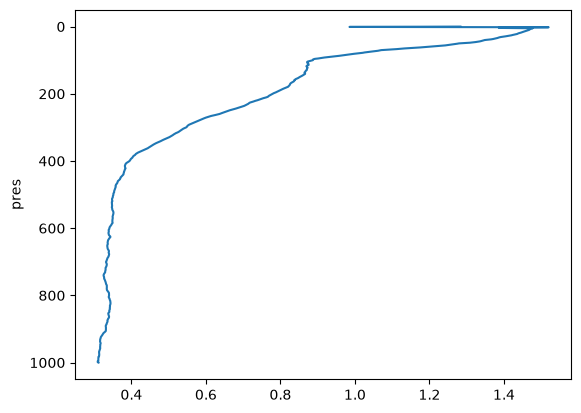

In [24]:
anom_mean.plot(y='pres')
plt.gca().invert_yaxis()